In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("cleaned_credit_applications.csv")

In [5]:
df.head()

,_id,spending_behavior,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,interest_rate,approved_amount,total_spending,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,73000.0,23.0,0.20,31212.0,False,algorithm_risk_score,0.0,0.0,1517,24.966461
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032,78000.0,51.0,0.18,17915.0,False,algorithm_risk_score,0.0,0.0,947,33.905544
2,app_215,"[{'category': 'Rent', 'amount': 109}]",Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,61000.0,41.0,0.21,37909.0,True,NaN,3.7,59000.0,109,36.339493
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,103000.0,70.0,0.35,0.0,True,NaN,4.3,34000.0,575,42.839151
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080,57000.0,14.0,0.23,31763.0,False,algorithm_risk_score,0.0,0.0,463,26.767967


In [6]:
df.columns

Index(['_id', 'spending_behavior', 'full_name', 'email', 'ssn', 'ip_address',
       'gender', 'date_of_birth', 'zip_code', 'annual_income',
       'credit_history_months', 'debt_to_income', 'savings_balance',
       'loan_approved', 'rejection_reason', 'interest_rate', 'approved_amount',
       'total_spending', 'age'],
      dtype='object')

In [7]:
df["loan_approved"].mean()

np.float64(0.5671641791044776)

In [8]:
df.groupby("gender")["loan_approved"].mean()

gender
Female    0.505952
Male      0.628743
Name: loan_approved, dtype: float64

## Disparate Impact (DI)

In [9]:
female = df[df["gender"] == "Female"]
male = df[df["gender"] == "Male"]

DI = female["loan_approved"].mean() / male["loan_approved"].mean()

print("Disparate Impact:", DI)

Disparate Impact: 0.8047052154195011


DI = Female approval rate / Male approval rate

The calculated DI is approximately 0.80.
This suggests that women are approved at about 80% the rate of men.

In [10]:
numerical_cols = [
    "annual_income",
    "debt_to_income",
    "savings_balance",
    "credit_history_months",
    "age",
    "loan_approved"
]

df[numerical_cols].corr()

,annual_income,debt_to_income,savings_balance,credit_history_months,age,loan_approved
annual_income,1.000000,-0.118625,0.650705,0.189005,0.398179,0.187743
debt_to_income,-0.118625,1.000000,-0.097102,-0.054396,-0.098347,0.023958
savings_balance,0.650705,-0.097102,1.000000,0.149431,0.277142,0.124884
credit_history_months,0.189005,-0.054396,0.149431,1.000000,0.663963,0.158849
age,0.398179,-0.098347,0.277142,0.663963,1.000000,0.162038
loan_approved,0.187743,0.023958,0.124884,0.158849,0.162038,1.000000


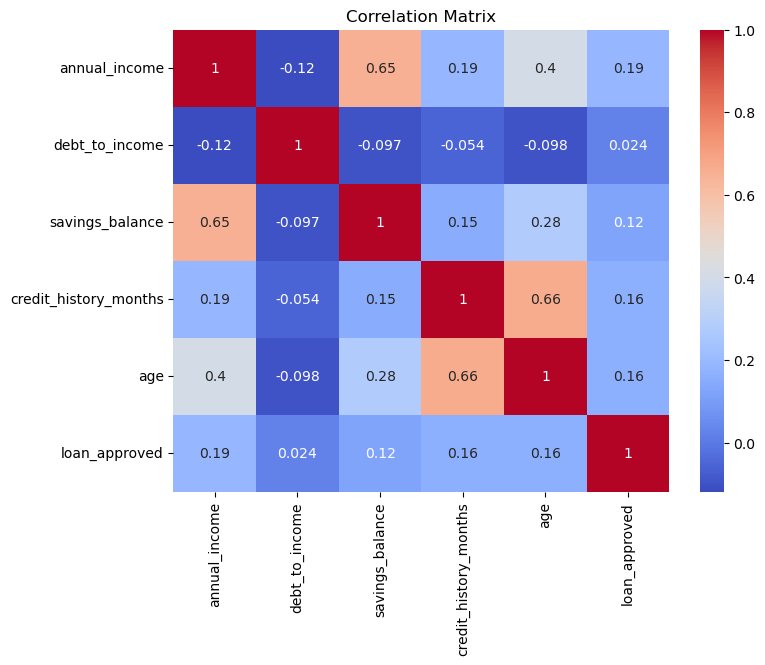

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Impact of Data Cleaning on Approval Metrics

After cleaning the data, the overall loan approval rate is about 56.7%.

When we look at gender:
- Female approval rate is about 50.6%
- Male approval rate is about 62.9%
- Disparate Impact is about 0.80

This shows that there is still a difference between men and women in loan approvals, even after cleaning the data.

## Age based anaysis

In [15]:
df.groupby("age")["loan_approved"].mean()

age
23.841205    1.0
24.175222    0.0
24.394251    0.0
24.399726    1.0
24.583162    1.0
            ... 
66.472279    0.0
67.151266    0.0
67.181383    1.0
67.266256    1.0
67.430527    1.0
Name: loan_approved, Length: 331, dtype: float64

In [16]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

In [17]:
df.groupby("age_group")["loan_approved"].mean()

/var/folders/mt/lqgwlp595qx61nxnr067btpm0000gn/T/ipykernel_38328/2461128598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean()


age_group
18-25    0.555556
26-35    0.418367
36-45    0.611570
46-55    0.677966
56-65    0.641026
Name: loan_approved, dtype: float64

/var/folders/mt/lqgwlp595qx61nxnr067btpm0000gn/T/ipykernel_38328/2173826309.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")


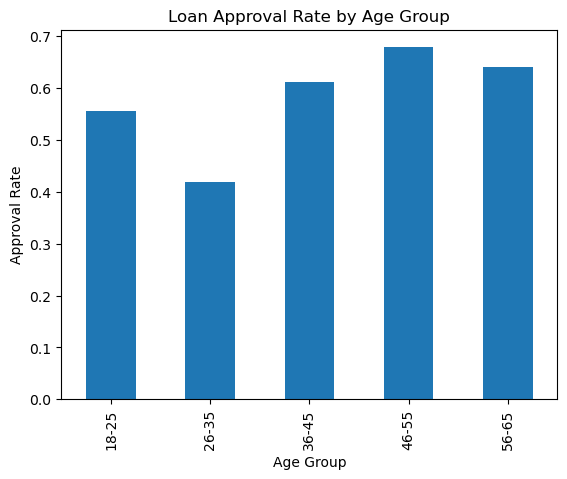

In [18]:
df.groupby("age_group")["loan_approved"].mean().plot(kind="bar")

plt.title("Loan Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.xlabel("Age Group")
plt.show()


Loan approval rates vary across age groups.

This suggests that age may influence loan approval decisions.
Further investigation is needed to determine if this difference indicates bias.